In [6]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.tree import plot_tree

In [8]:
df = pd.read_csv("/content/student_pass_prediction.csv")
df.info()

,Study_Hours,Attendance,Previous_Score,Assignments,Pass
count,20.00000,20.000000,20.000000,20.000000,20.000000
mean,4.45000,76.900000,66.350000,6.650000,0.600000
std,2.32775,12.652855,16.572885,2.560325,0.502625
min,1.00000,55.000000,40.000000,2.000000,0.000000
25%,2.75000,67.250000,53.750000,4.750000,0.000000
50%,4.50000,79.000000,67.500000,7.000000,1.000000
75%,6.00000,87.250000,79.250000,9.000000,1.000000
max,9.00000,96.000000,94.000000,10.000000,1.000000


In [19]:
X = df.drop("Pass",axis =1)
df["Pass"] = df["Pass"].map({
    0: "Fail",
    1: "Pass"
})
Y = df["Pass"]

In [20]:
X_train,X_test,Y_train,Y_test =train_test_split(X,Y,test_size = 0.3,random_state =42,stratify=Y)

In [22]:
model = DecisionTreeClassifier(random_state =42)
model.fit(X_test,Y_test)

DecisionTreeClassifier(random_state=42)

In [23]:
y_pred = model.predict(X_test)
print(y_pred)

['Fail' 'Pass' 'Fail' 'Pass' 'Pass' 'Pass']


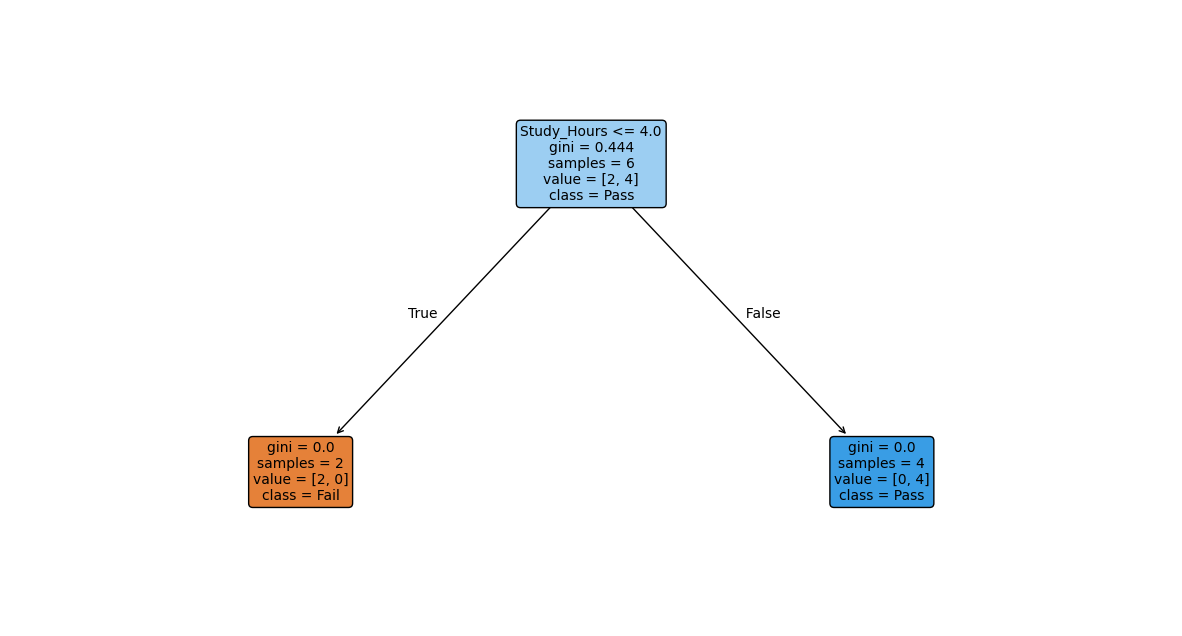

In [24]:
plt.figure(figsize=(15,8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Fail", "Pass"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.show()

In [17]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

          Feature  Importance
0     Study_Hours         1.0
1      Attendance         0.0
2  Previous_Score         0.0
3     Assignments         0.0


In [18]:
accuracy = accuracy_score(Y_test, y_pred)

print("Accuracy:", accuracy * 100)
cm = confusion_matrix(Y_test, y_pred)

print(cm)
print(classification_report(Y_test, y_pred))

Accuracy: 100.0
[[2 0]
 [0 4]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         4

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



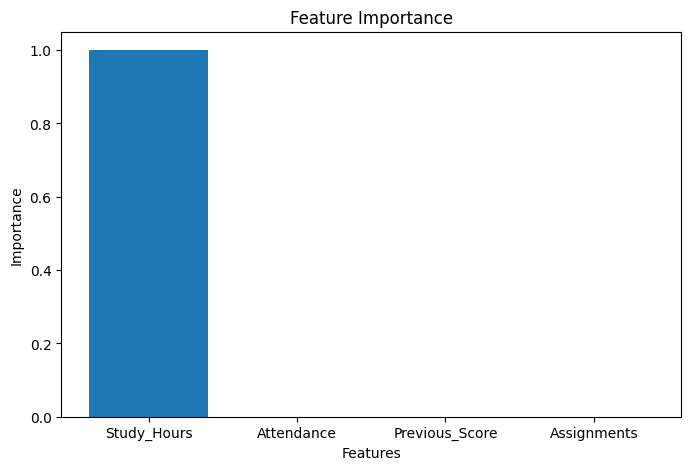

In [25]:
plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()